# EEG Lab — Notebook 4: time-frequency representation

**Goal:** see how the frequency content **evolves over time**, and spot the moment the subject closes their eyes.

The spectrum from the previous notebook summarizes everything over the whole duration. Here we want a 2D image: time on the x-axis, frequency on the y-axis, and power as color. This is the **spectrogram**.

## 1. Reload the full signal (both conditions in a row)


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, spectrogram

df = pd.read_csv('eeg_data.csv')
fs = 250

def band_pass(signal, low, high, fs, order=4):
    nyq = fs/2
    b, a = butter(order, [low/nyq, high/nyq], btype='band')
    return filtfilt(b, a, signal)

o1 = band_pass(df['O1'].to_numpy(), 1, 40, fs)
marker = df['marker'].to_numpy()
# instant (in s) when we switch from eyes open to eyes closed
transition = np.argmax(marker == 1) / fs
print("The subject closes their eyes at t =", round(transition, 1), "s")

The subject closes their eyes at t = 30.0 s


## 2. Compute the spectrogram

`spectrogram` slides a window along the signal and computes a spectrum at each position. We get:
- `f`: the frequencies,
- `t`: the time instants,
- `Sxx`: the power (a frequency × time array).

In [2]:
f, t, Sxx = spectrogram(o1, fs, nperseg=fs*2, noverlap=fs)

print("Power array Sxx:", Sxx.shape, "(frequencies, instants)")

Power array Sxx: (251, 59) (frequencies, instants)


## 3. Display the spectrogram

We switch to decibels (`10*log10`) to see contrasts better, and limit the display to 1–40 Hz.

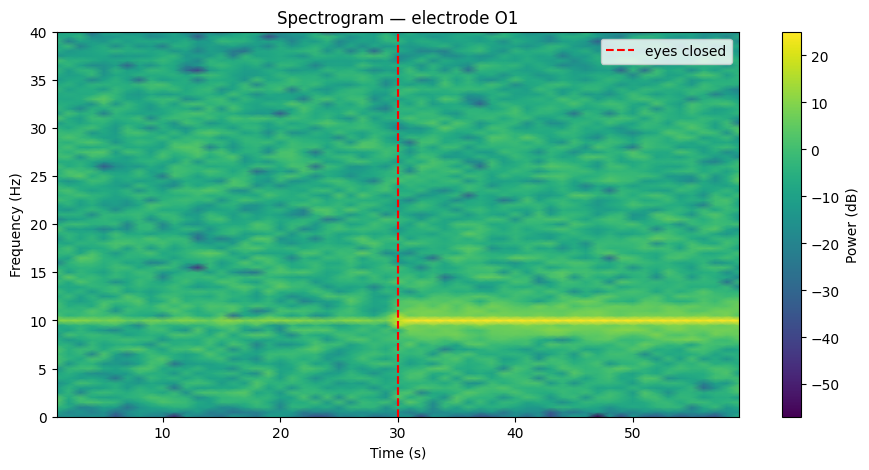

In [3]:
keep = f <= 40

plt.figure(figsize=(11, 5))
plt.pcolormesh(t, f[keep], 10*np.log10(Sxx[keep] + 1e-12), shading='gouraud')
plt.axvline(transition, color='red', linestyle='--', label='eyes closed')
plt.ylabel("Frequency (Hz)")
plt.xlabel("Time (s)")
plt.title("Spectrogram — electrode O1")
plt.colorbar(label="Power (dB)")
plt.legend(loc='upper right')
plt.show()

👀 **Notice** the horizontal band that lights up around 10 Hz **after** the red line: alpha appears when the eyes close.

## 4. Going further: wavelets with MNE-Python

`MNE` is *the* reference library for EEG/MEG. It offers time-frequency analysis with **Morlet wavelets**, often more readable than the spectrogram for brain rhythms.

> ⚠️ This section requires installing MNE (`pip install mne`). If that's not possible on the lab machines, the spectrogram above is more than enough.

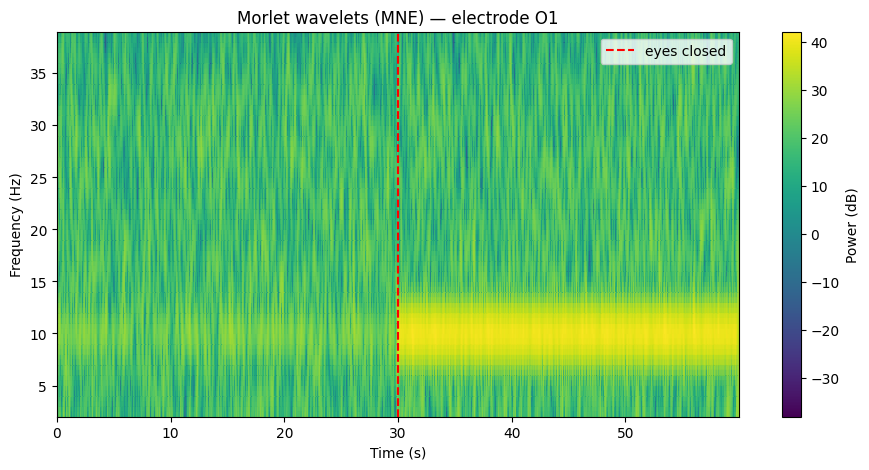

In [4]:
# Uncomment to install if needed:
# !pip install mne

try:
    import mne
    from mne.time_frequency import tfr_array_morlet

    # MNE expects the shape (epochs, channels, time)
    data = o1[np.newaxis, np.newaxis, :]
    freqs = np.arange(2, 40, 1.0)
    n_cycles = freqs / 2.0
    power = tfr_array_morlet(data, sfreq=fs, freqs=freqs,
                             n_cycles=n_cycles, output='power')
    power = power[0, 0]   # -> (frequencies, time)

    time = np.arange(o1.shape[0]) / fs
    plt.figure(figsize=(11, 5))
    plt.pcolormesh(time, freqs, 10*np.log10(power + 1e-12), shading='gouraud')
    plt.axvline(transition, color='red', linestyle='--', label='eyes closed')
    plt.ylabel('Frequency (Hz)'); plt.xlabel('Time (s)')
    plt.title('Morlet wavelets (MNE) — electrode O1')
    plt.colorbar(label='Power (dB)'); plt.legend(loc='upper right')
    plt.show()
except ImportError:
    print("MNE is not installed: we stop at the spectrogram, which is fine too.")

## 🧠 Your turn — lab wrap-up

1. Redo the spectrogram for **O2** and a frontal electrode (**Fp1**). Compare: where do you see the alpha effect best?
2. **Interpretation question:** why is alpha more pronounced on the occipital electrodes (O1, O2) than the frontal ones?
3. **Bonus:** loop over all 8 channels with a `for` loop and compute, for each one, the closed/open alpha power ratio. Which channel gives the largest effect?

*Well done: you went from the raw signal all the way to a full time-frequency analysis!*

In [5]:
# Your code here
